# 🎌 Anime Recommendation System — Content-Based Filtering

**Dataset:** [Anime Recommendations Database (Kaggle)](https://www.kaggle.com/code/benroshan/content-collaborative-anime-recommendation)
`anime.csv` — 12,294 anime with `anime_id, name, genre, type, episodes, rating, members`.

**Goals of this notebook**
1. Load the dataset
2. Exploratory Data Analysis (EDA) + visualizations
3. Check distributions / skewness of numeric variables, apply transformations where needed
4. Build a **content-based recommender system** (genre + type similarity, TF-IDF + cosine nearest neighbors)
5. Persist the trained artifacts so the companion **Streamlit app** (`app.py`) can serve recommendations instantly

> Note: the original Kaggle notebook this project is based on also builds a *collaborative-filtering* model using
> a separate `rating.csv` (user ↔ anime ratings) file. That file was not provided here — only `anime.csv` was —
> so this notebook focuses on the **content-based** system, which only needs anime metadata.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Local project module (shared with the Streamlit app — see recommender.py)
import sys, os
sys.path.append(os.path.abspath(".."))
import recommender as rec

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

%matplotlib inline


## 1. Load the Dataset

In [ ]:
DATA_PATH = "anime.csv"
raw_df = rec.load_raw_data(DATA_PATH)
print("Shape:", raw_df.shape)
raw_df.head()


Shape: (12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [3]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 1.3 MB


In [4]:
raw_df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
anime_id,12294.0,NaN,NaN,NaN,14058.221653,11455.294701,1.0,3484.25,10260.5,24794.5,34527.0
name,12294,12292,Saru Kani Gassen,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,12232,3264,Hentai,823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,12269,6,TV,3787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
episodes,12294,187,1,5677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,12064.0,NaN,NaN,NaN,6.473902,1.026746,1.67,5.88,6.57,7.18,10.0
members,12294.0,NaN,NaN,NaN,18071.338864,54820.676925,5.0,225.0,1550.0,9437.0,1013917.0


## 2. Exploratory Data Analysis (EDA)

First, let's understand data quality (missing values, weird placeholder strings like `'Unknown'` in `episodes`),
then visualize the shape of the data.

In [5]:
# Missing values
missing = raw_df.isnull().sum()
missing_pct = (missing / len(raw_df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
anime_id,0,0.00
name,0,0.00
genre,62,0.50
type,25,0.20
episodes,0,0.00
rating,230,1.87
members,0,0.00


In [6]:
# 'episodes' hides missing values as the literal string 'Unknown'
print("Literal 'Unknown' values in episodes:", (raw_df['episodes'] == 'Unknown').sum())
raw_df['episodes'].unique()[:15]


Literal 'Unknown' values in episodes: 340


<ArrowStringArray>
[  '1',  '64',  '51',  '24',  '10', '148', '110',  '13', '201',  '25',  '22',
  '75',   '4',  '26',  '12']
Length: 15, dtype: str

### 2.1 Clean the data
Using the shared `recommender.py` cleaning pipeline so the notebook and the Streamlit app always stay in sync.

In [7]:
df = rec.clean_data(raw_df)
df = rec.add_transformed_features(df)

print("Shape after cleaning:", df.shape)
print("\nRemaining missing values:\n", df[['genre','type','episodes','rating','members']].isnull().sum())
df.head()


Shape after cleaning: (12294, 9)

Remaining missing values:
 genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


,anime_id,name,genre,type,episodes,rating,members,members_log,episodes_log
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630,12.209223,0.693147
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665,13.584418,4.174387
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262,11.646258,3.951244
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572,13.420352,3.218876
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266,11.926802,3.951244


### 2.2 Categorical distributions

C:\Users\nmsha\AppData\Local\Temp\ipykernel_22696\3369578099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[0], palette="viridis")
C:\Users\nmsha\AppData\Local\Temp\ipykernel_22696\3369578099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[1], palette="magma")


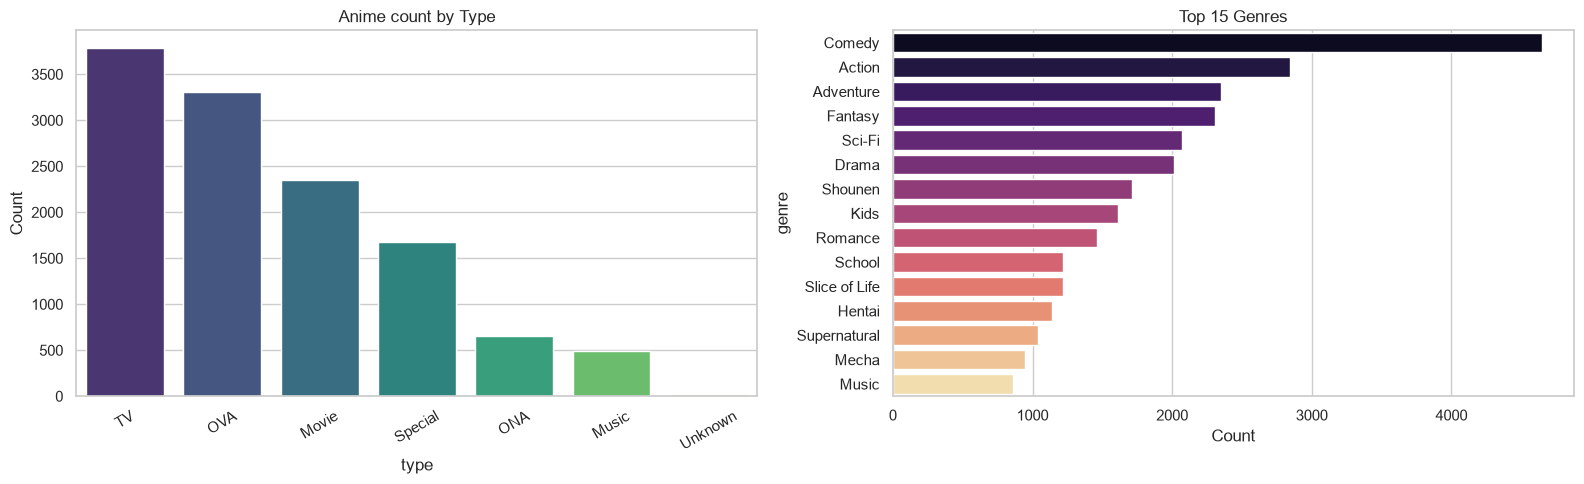

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

type_counts = df['type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Anime count by Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

genre_counts = df['genre'].str.split(', ').explode().value_counts().head(15)
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[1], palette="magma")
axes[1].set_title("Top 15 Genres")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()


### 2.3 Numeric distributions

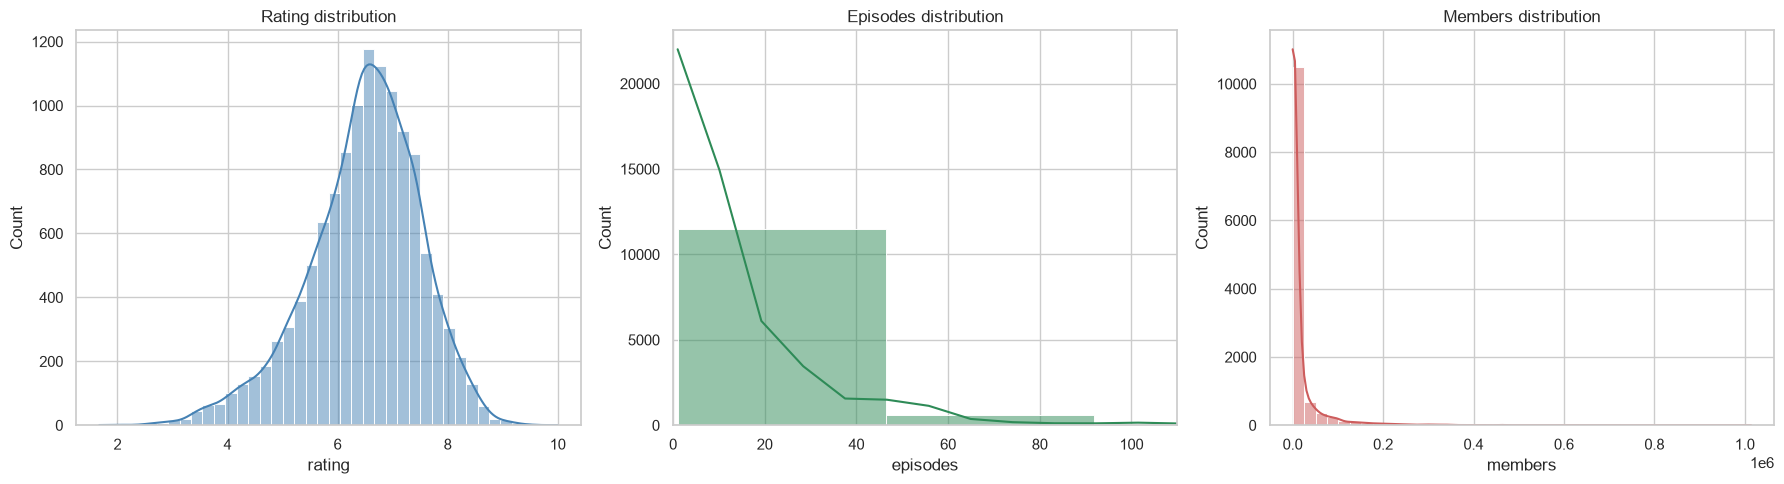

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['rating'], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Rating distribution")

sns.histplot(df['episodes'], bins=40, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Episodes distribution")
axes[1].set_xlim(0, df['episodes'].quantile(0.99))

sns.histplot(df['members'], bins=40, kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Members distribution")

plt.tight_layout()
plt.show()


### 2.4 Relationships between variables

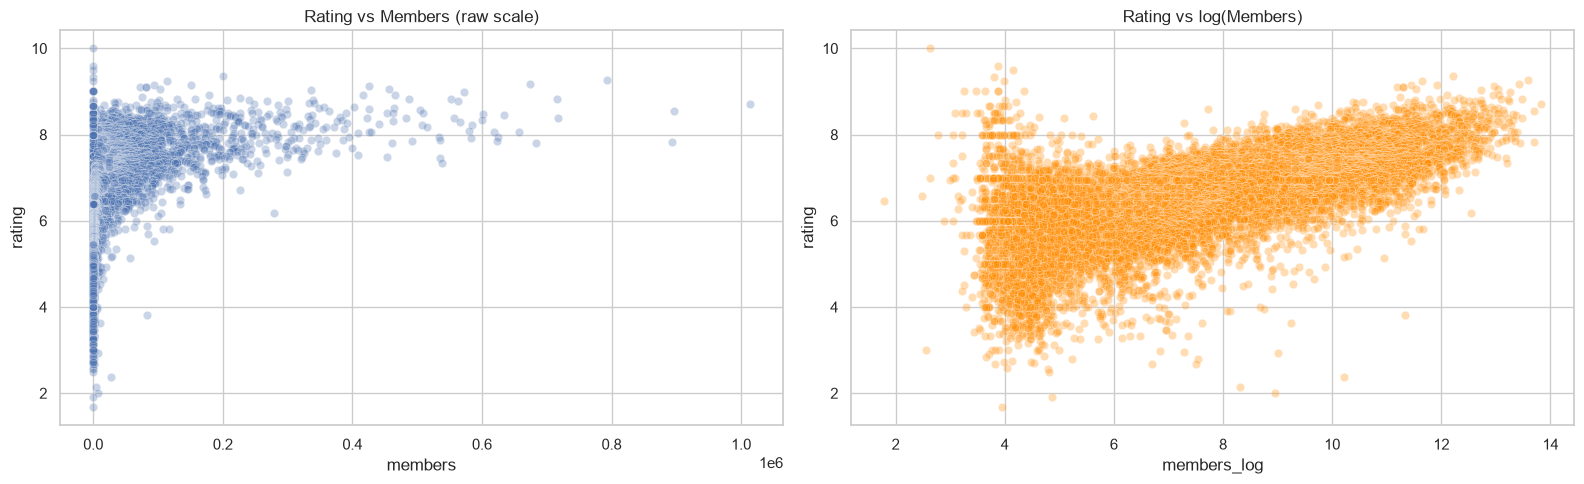

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(data=df, x="members", y="rating", alpha=0.3, ax=axes[0])
axes[0].set_title("Rating vs Members (raw scale)")

sns.scatterplot(data=df, x="members_log", y="rating", alpha=0.3, ax=axes[1], color="darkorange")
axes[1].set_title("Rating vs log(Members)")

plt.tight_layout()
plt.show()


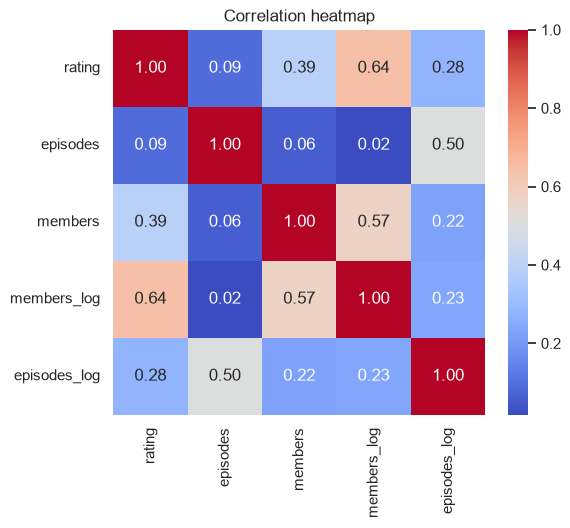

In [11]:
plt.figure(figsize=(6, 5))
numeric_cols = ['rating', 'episodes', 'members', 'members_log', 'episodes_log']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()


C:\Users\nmsha\AppData\Local\Temp\ipykernel_22696\3186958449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['type'].isin(top_types)], x="type", y="rating", palette="Set2")


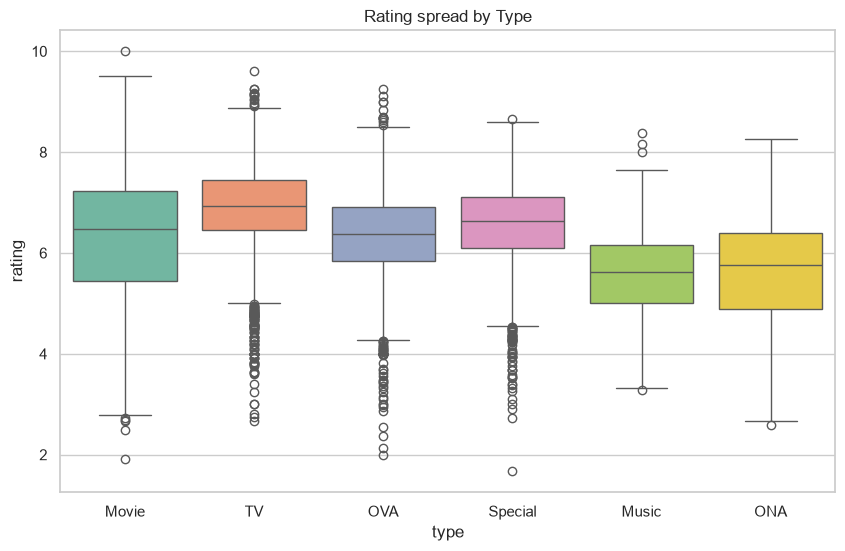

In [12]:
plt.figure(figsize=(10, 6))
top_types = df['type'].value_counts().head(6).index
sns.boxplot(data=df[df['type'].isin(top_types)], x="type", y="rating", palette="Set2")
plt.title("Rating spread by Type")
plt.show()


## 3. Skewness Analysis & Transformations

Right-skewed distributions (long tail of a few mega-popular / very-long-running anime) can distort
distance-based models and make visualizations hard to read. We quantify skewness with
`scipy.stats.skew` and apply a `log1p` transform where it's large.

**Rule of thumb used here:** `|skewness| > 1` → apply `log1p` transform.

In [13]:
skew_report = pd.DataFrame({
    "variable": ["rating", "episodes", "members"],
    "skewness": [skew(df["rating"]), skew(df["episodes"]), skew(df["members"])]
})
skew_report["interpretation"] = skew_report["skewness"].apply(
    lambda s: "highly skewed -> transform" if abs(s) > 1 else
              ("moderately skewed" if abs(s) > 0.5 else "fairly symmetric")
)
skew_report


,variable,skewness,interpretation
0,rating,-0.557950,moderately skewed
1,episodes,23.650063,highly skewed -> transform
2,members,6.682119,highly skewed -> transform


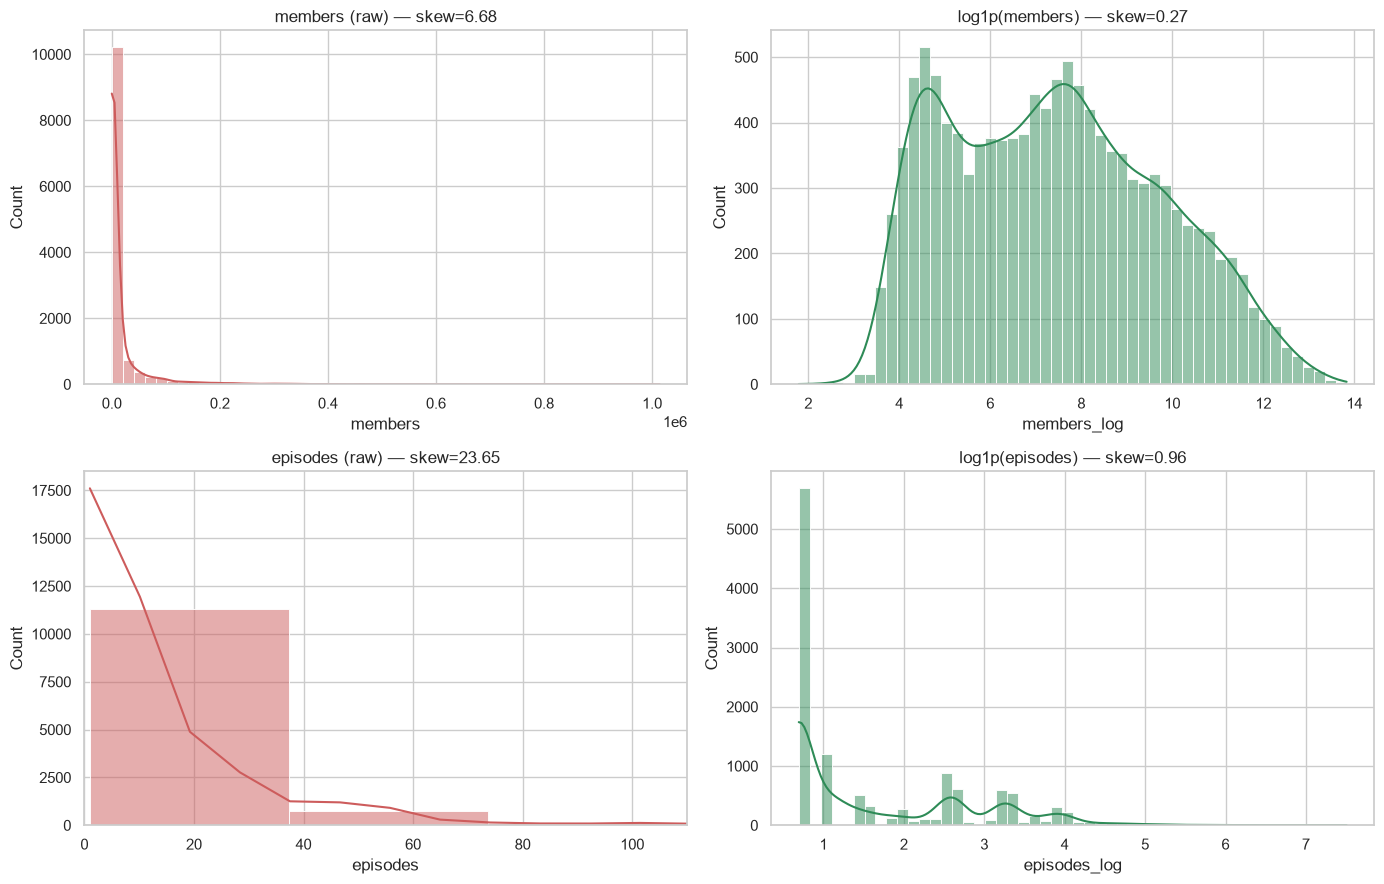

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df['members'], bins=50, kde=True, ax=axes[0,0], color="indianred")
axes[0,0].set_title(f"members (raw) — skew={skew(df['members']):.2f}")

sns.histplot(df['members_log'], bins=50, kde=True, ax=axes[0,1], color="seagreen")
axes[0,1].set_title(f"log1p(members) — skew={skew(df['members_log']):.2f}")

sns.histplot(df['episodes'], bins=50, kde=True, ax=axes[1,0], color="indianred")
axes[1,0].set_title(f"episodes (raw) — skew={skew(df['episodes']):.2f}")
axes[1,0].set_xlim(0, df['episodes'].quantile(0.99))

sns.histplot(df['episodes_log'], bins=50, kde=True, ax=axes[1,1], color="seagreen")
axes[1,1].set_title(f"log1p(episodes) — skew={skew(df['episodes_log']):.2f}")

plt.tight_layout()
plt.show()


**Findings:**
- `rating` is close to a normal / bell-shaped distribution (skew near 0) → **no transform needed**.
- `members` is heavily right-skewed (a small number of blockbuster anime like *Death Note* / *Naruto* dominate) →
  `log1p(members)` brings it much closer to symmetric, and is what we use for any downstream numeric modeling or
  for the "popularity filter" bucketing in the app.
- `episodes` is also right-skewed (a few long-running series with 500+ episodes) →  `log1p(episodes)` similarly helps.

These log-transformed columns (`members_log`, `episodes_log`) are kept in the cleaned dataframe for optional use,
but the core **content-based similarity** below is driven by `genre` + `type` text features, which don't require
this numeric transformation — it mainly matters if you extend the model with numeric similarity too (see §5).

## 4. Content-Based Recommender System

**Approach**
1. Build a "content soup" per anime: its `genre` tags + `type`, each kept as a single token
   (e.g. `Sci-Fi` stays one token instead of being split into `Sci` and `Fi`).
2. Vectorize the soup with **TF-IDF**.
3. Fit a **NearestNeighbors** index with cosine distance over the TF-IDF matrix.
4. To recommend: look up an anime's TF-IDF row → find its nearest neighbors → return the closest titles
   (optionally filtered by type / minimum popularity).

We use `NearestNeighbors` instead of materializing a full N×N cosine-similarity matrix because with ~12,000
titles a dense similarity matrix would need >1GB of memory — wasteful for something we can query on-the-fly in
milliseconds.

In [15]:
soup_sample = rec.build_soup(df)
soup_sample.head()


0              Drama Romance School Supernatural Movie
1    Action Adventure Drama Fantasy Magic Military ...
2    Action Comedy Historical Parody Samurai Sci_Fi...
3                                   Sci_Fi Thriller TV
4    Action Comedy Historical Parody Samurai Sci_Fi...
dtype: str

In [16]:
vectorizer, tfidf_matrix, nn_model = rec.build_content_model(df)
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))


TF-IDF matrix shape: (12294, 49)
Vocabulary size: 49


### 4.1 Try it out

In [17]:
recs, matched = rec.get_recommendations("Naruto", df, tfidf_matrix, nn_model, top_n=10)
print(f"Because you liked: {matched}\n")
recs


Because you liked: Naruto



,name,genre,type,episodes,rating,members,similarity
0,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,24.0,7.94,533578,1.000000
1,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",OVA,1.0,7.58,23465,0.922972
2,Rekka no Honoo,"Action, Adventure, Martial Arts, Shounen, Supe...",TV,42.0,7.44,35258,0.918257
3,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,1.0,7.50,83515,0.911224
4,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,1.0,7.53,84527,0.911224
5,Boruto: Naruto the Movie,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,1.0,8.03,74690,0.911224
6,Naruto Soyokazeden Movie: Naruto to Mashin to ...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,1.0,7.11,25174,0.911224
7,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,291.0,8.32,375662,0.906177
8,Dragon Ball Kai (2014),"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,61.0,8.01,42666,0.906177
9,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,97.0,7.95,116832,0.906177


In [18]:
recs2, matched2 = rec.get_recommendations("Death Note", df, tfidf_matrix, nn_model, top_n=10)
print(f"Because you liked: {matched2}\n")
recs2


Because you liked: Death Note



,name,genre,type,episodes,rating,members,similarity
0,Mousou Dairinin,"Drama, Mystery, Police, Psychological, Superna...",TV,13.0,7.74,137687,0.968911
1,Death Note Rewrite,"Mystery, Police, Psychological, Supernatural, ...",Special,2.0,7.84,88699,0.944472
2,Higurashi no Naku Koro ni Kai,"Mystery, Psychological, Supernatural, Thriller",TV,24.0,8.41,218101,0.884548
3,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,26.0,8.07,657190,0.822170
4,Higurashi no Naku Koro ni Rei,"Comedy, Mystery, Psychological, Supernatural, ...",OVA,5.0,7.56,99463,0.820930
5,Higurashi no Naku Koro ni,"Horror, Mystery, Psychological, Supernatural, ...",TV,26.0,8.17,359494,0.802674
6,Monster,"Drama, Horror, Mystery, Police, Psychological,...",TV,74.0,8.72,247562,0.797930
7,Mirai Nikki (TV): Ura Mirai Nikki,"Action, Comedy, Mystery, Psychological, Shoune...",Special,10.0,6.79,32565,0.753566
8,AD Police,"Adventure, Dementia, Mecha, Mystery, Police, P...",OVA,3.0,6.47,6112,0.745537
9,Zankyou no Terror,"Psychological, Thriller",TV,11.0,8.26,342893,0.732177


### 4.2 Visualize a recommendation result

C:\Users\nmsha\AppData\Local\Temp\ipykernel_22696\1864652599.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recs_viz.sort_values("similarity"), x="similarity", y="name", palette="crest")


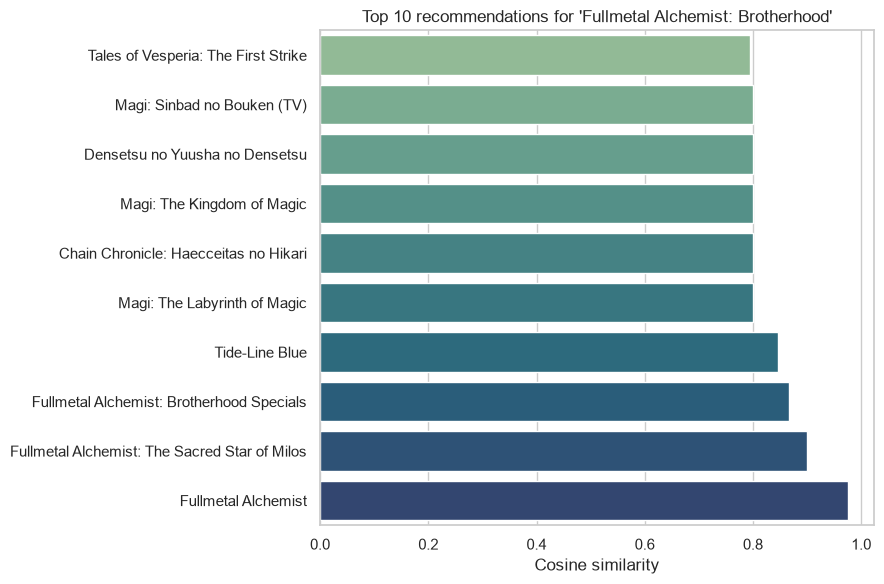

In [19]:
recs_viz, matched_viz = rec.get_recommendations("Fullmetal Alchemist: Brotherhood", df, tfidf_matrix, nn_model, top_n=10)

plt.figure(figsize=(9, 6))
sns.barplot(data=recs_viz.sort_values("similarity"), x="similarity", y="name", palette="crest")
plt.title(f"Top 10 recommendations for '{matched_viz}'")
plt.xlabel("Cosine similarity")
plt.ylabel("")
plt.tight_layout()
plt.show()


### 4.3 Filtered recommendations (only highly-rated TV series)

In [20]:
recs_f, matched_f = rec.get_recommendations(
    "One Piece", df, tfidf_matrix, nn_model, top_n=10, anime_type="TV", min_members=50000
)
print(f"Because you liked: {matched_f}\n")
recs_f


Because you liked: One Piece



,name,genre,type,episodes,rating,members,similarity
0,Shingeki no Kyojin Season 2,"Action, Drama, Fantasy, Shounen, Super Power",TV,24.0,6.94,170054,0.910293
1,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25.0,8.54,896229,0.910293
2,Digimon Frontier,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",TV,50.0,7.25,74929,0.845056
3,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148.0,9.13,425855,0.838930
4,Hunter x Hunter,"Action, Adventure, Shounen, Super Power",TV,62.0,8.48,166255,0.838930
5,Katekyo Hitman Reborn!,"Action, Comedy, Shounen, Super Power",TV,203.0,8.37,258103,0.808933
6,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",TV,64.0,6.72,226625,0.793949
7,Digimon Tamers,"Adventure, Comedy, Drama, Fantasy, Shounen",TV,51.0,7.65,94391,0.786831
8,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,97.0,7.95,116832,0.786420
9,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,291.0,8.32,375662,0.786420


## 5. (Optional) Sanity check — does the model make sense?

A quick qualitative check: genres of the queried anime vs. genres of its top recommendation should overlap heavily.

In [21]:
def genre_overlap_check(title):
    recs, matched = rec.get_recommendations(title, df, tfidf_matrix, nn_model, top_n=5)
    query_genres = set(df.loc[df['name'] == matched, 'genre'].iloc[0].split(', '))
    print(f"Query: {matched}")
    print(f"  Genres: {query_genres}\n")
    for _, row in recs.iterrows():
        rec_genres = set(row['genre'].split(', '))
        overlap = query_genres & rec_genres
        print(f"  -> {row['name']:<45} overlap={len(overlap)}/{len(query_genres)}  {overlap}")

genre_overlap_check("Naruto")


Query: Naruto
  Genres: {'Comedy', 'Martial Arts', 'Shounen', 'Super Power', 'Action'}

  -> Naruto: Shippuuden                            overlap=5/5  {'Comedy', 'Martial Arts', 'Shounen', 'Super Power', 'Action'}
  -> Naruto x UT                                   overlap=5/5  {'Comedy', 'Martial Arts', 'Shounen', 'Super Power', 'Action'}
  -> Rekka no Honoo                                overlap=4/5  {'Action', 'Shounen', 'Super Power', 'Martial Arts'}
  -> Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono overlap=5/5  {'Comedy', 'Martial Arts', 'Shounen', 'Super Power', 'Action'}
  -> Naruto: Shippuuden Movie 4 - The Lost Tower   overlap=5/5  {'Comedy', 'Martial Arts', 'Shounen', 'Super Power', 'Action'}


## 6. Persist Model Artifacts

Save the cleaned dataframe + TF-IDF vectorizer + TF-IDF matrix to `../models/`.
`app.py` (Streamlit) loads these directly so the app starts instantly without re-training.

In [22]:
rec.save_artifacts(df, vectorizer, tfidf_matrix, "../models")


Artifacts saved to ../models


## 7. Next Steps / How to Run the App

```bash
# from the project root (one level up from notebooks/)
pip install -r requirements.txt
streamlit run app.py
```

The app has two pages:
- **🔍 Get Recommendations** — pick any anime, get similar titles, with type/popularity filters
- **📊 Dataset Explorer** — interactive recap of the EDA above (distributions, skewness, top genres)

**Possible extensions**
- Add the MyAnimeList `rating.csv` (user–anime ratings) to build a true **collaborative-filtering** model
  (matrix factorization / SVD) and combine it with this content-based model into a **hybrid recommender**.
- Weight genre similarity by `rating`/`members` so popular, well-reviewed anime are ranked slightly higher
  among equally-similar candidates.
- Use anime synopses (if available) with sentence embeddings instead of / in addition to genre tags for
  richer content similarity.
